In [994]:
from tradepy.data.loader import load_future
from tradepy.config.config import load_config, load_symbols, load_feature_config, load_exclude_config
from tradepy.data.loader import load_specs
from tradepy.data.cleaner import add_trading_date_by_gap
from tradepy.data.resampler import resample_ohlcv, daily_ohlcv_cummulative
from tradepy.features.generate import generate_features
from tradepy.features.quality_check import data_quality_report
from tradepy.supervised.load import prepare_all
from tradepy.paths import EXCLUDE_CONFIG, SYSTEM_CONFIG
from tradepy.supervised.target import target_triple_barrier_interday
from tradepy.supervised.pretrain import filter_features
from tradepy.supervised.models import GoldLSTM_L1_Move, GoldLSTM_L2_Dir, GoldGRU_L1_Move, GoldGRU_L2_Dir, BasicLSTM_L1_Move, BasicLSTM_L2_Dir, BasicGRU_L1_Move, BasicGRU_L2_Dir, BasicLSTM_L3_Regression, BasicGRU_L3_Regression
from tradepy.supervised.train import train_walk_forward_2level, grid_search_thresholds, create_lstm_dataset
from tradepy.supervised.posttrain import evaluate_model_classification, tune_threshold_wf, save_trading_model_2level, load_trading_model_3level
from tradepy.paths import MODELS_DIR, BT_DIR

import pandas as pd

In [995]:
symbols = load_symbols()
cfg = load_config()

In [996]:
symbols

['AD',
 'BP',
 'CL',
 'EC',
 'ES',
 'GC',
 'MFXI',
 'NG',
 'NQ',
 'YM',
 'ZB',
 'ZN',
 'ZS']

In [997]:
ASSET = symbols[12]
MINUTES             = cfg['sampling_minutes']        # 240
RETURN_HORIZON_MIN  = cfg['return_horizon_min']      # 2880

In [998]:
(
    model_l1,
    model_l2,
    model_l3,
    sc_features,
    sc_l3,
    features,
    params,
    thresholds,
    df_results
) = load_trading_model_3level(
        BasicLSTM_L1_Move,
        BasicLSTM_L2_Dir,
        BasicLSTM_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_lstm_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/trading_model_lstm_3level
📌 Features: 73
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [999]:
(
    model_l1_g,
    model_l2_g,
    model_l3_g,
    sc_features_g,
    sc_l3_g,
    features_g,
    params_g,
    thresholds_g,
    df_results_g
) = load_trading_model_3level(
        BasicGRU_L1_Move,
        BasicGRU_L2_Dir,
        BasicGRU_L3_Regression,
        path=f"{MODELS_DIR}/{ASSET.lower()}/trading_model_gru_3level",
        device="cuda"
)


🚀 Pipeline 3-Level cargado correctamente desde: E:\Futuro\MLAlgoTrading\TradingBots\Models/zs/trading_model_gru_3level
📌 Features: 73
📌 Thresholds cargados: True
📁 Resultados cargados: True


In [1000]:
ASSET

'ZS'

In [1001]:
def load_bt_csv(ticker):
    data = pd.read_parquet(f"{BT_DIR}/{ticker}1min.parquet")
    data["openint"] = 0
    data["datetime"] = pd.to_datetime(data["time"], utc=True)
    # Cargar specs
    specs = load_specs()
    ticker = ticker.upper()
    if ticker not in specs:
        raise KeyError(f"No se encuentra spec para '{ticker}' en los JSON de info.")
    data = data.sort_values('datetime').drop_duplicates(subset='datetime').reset_index(drop=True)
    return data, specs[ticker]
    # return data

In [1002]:
def prepare_bt(symbol, minutes, return_horizon_min, json_config_path="features_config.json"):
    df, spec = load_bt_csv(symbol)
    df = add_trading_date_by_gap(df)
    df_resampled = resample_ohlcv(df, period=f"{minutes}min")
    df_cumulative = daily_ohlcv_cummulative(df_resampled)
    config = load_feature_config()

    config["global"]["sampling_minutes"] = minutes
    config["global"]["return_horizon_min"] = return_horizon_min
    config["global"]["tick_size"] = spec["tick_size"]
    
    df_final = generate_features(df_cumulative, config)
    df_final["ticker"] = symbol
    return df_final, spec

In [1003]:
df_bt, spec_bt = prepare_bt(ASSET, MINUTES, RETURN_HORIZON_MIN, json_config_path="../Data/features_config.json")

In [1004]:
df_bt

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,nearest_fib_level,dist_to_nearest_fib,swing_extension,bars_between_swing_highs,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker
0,2025-12-22 04:00:00+00:00,1081.50,1085.50,1081.50,1085.25,445.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
1,2025-12-22 08:00:00+00:00,1085.25,1086.75,1085.25,1086.50,233.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
2,2025-12-22 12:00:00+00:00,1086.00,1086.25,1083.75,1084.25,151.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
3,2025-12-22 16:00:00+00:00,1084.25,1088.75,1083.50,1087.00,1891.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
4,2025-12-22 20:00:00+00:00,1087.50,1087.50,1084.25,1085.75,1771.0,0.0,240min,2025-12-22,1081.5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ZS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,2026-06-18 04:00:00+00:00,1132.00,1133.50,1129.25,1129.50,1479.0,0.0,240min,2026-06-18,1132.0,...,0.618,0.048667,-0.333333,4.0,4.0,8.25,3.3125,5.0,0.2,ZS
605,2026-06-18 08:00:00+00:00,1129.25,1134.75,1128.75,1131.75,1369.0,0.0,240min,2026-06-18,1132.0,...,0.786,-0.051152,-0.265152,4.0,4.0,8.25,3.3125,5.0,0.4,ZS
606,2026-06-18 12:00:00+00:00,1131.75,1132.00,1120.00,1121.25,3910.0,0.0,240min,2026-06-18,1132.0,...,0.382,0.034667,-0.583333,4.0,4.0,8.25,3.3125,5.0,0.6,ZS
607,2026-06-18 16:00:00+00:00,1121.50,1128.00,1118.50,1121.75,18110.0,0.0,240min,2026-06-18,1132.0,...,0.382,0.049818,-0.568182,4.0,4.0,8.25,3.3125,5.0,0.8,ZS


In [1005]:
start = "2026-03-27"
end   = "2026-06-01"

mask = (df_bt["datetime"] >= start) & (df_bt["datetime"] < end)
df_filtered = df_bt.loc[mask]


In [1006]:
df_bt["datetime"].dt.hour

0       4
1       8
2      12
3      16
4      20
       ..
604     4
605     8
606    12
607    16
608    20
Name: datetime, Length: 609, dtype: int32

<Axes: ylabel='Frequency'>

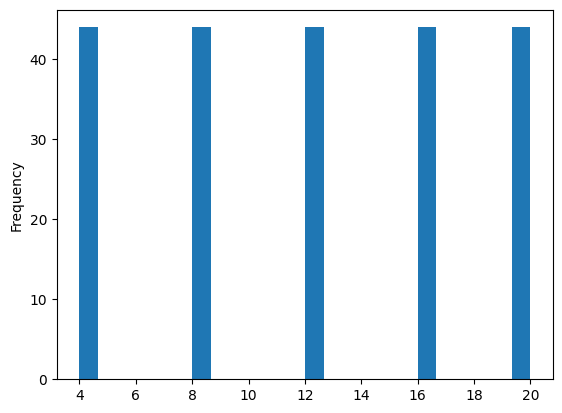

In [1007]:
df_filtered["hour"] = df_filtered["datetime"].dt.hour
df_filtered["hour"].plot.hist(bins=24)


In [1008]:
import numpy as np
import pandas as pd

def create_test_dataset(df, features, lookback=30):
    """
    Crea el dataset para LSTM usando NumPy strides (ultra rápido)
    y devuelve también los datetimes objetivo.
    
    Returns:
        X: np.ndarray de shape (num_samples, lookback, num_features)
        target_dt: pd.Series con los datetimes a predecir
    """
    # 1. Convertimos features a NumPy array
    feature_array = df[features].values
    
    # 2. Calculamos dimensiones
    num_samples = len(df) - lookback
    num_features = len(features)
    
    # 3. Crear ventanas con strides
    shape = (num_samples, lookback, num_features)
    strides = (feature_array.strides[0], feature_array.strides[0], feature_array.strides[1])
    
    X = np.lib.stride_tricks.as_strided(feature_array, shape=shape, strides=strides)
    
    # 4. Datetimes objetivo (los timestamps que vas a predecir)
    target_dt = df["datetime"].iloc[lookback:].reset_index(drop=True)
    
    return X, target_dt


In [1009]:
test, test_dt = create_test_dataset(df_filtered, features, lookback=30)

In [1010]:
test_dt

0     2026-04-07 04:00:00+00:00
1     2026-04-07 08:00:00+00:00
2     2026-04-07 12:00:00+00:00
3     2026-04-07 16:00:00+00:00
4     2026-04-07 20:00:00+00:00
                 ...           
185   2026-05-29 04:00:00+00:00
186   2026-05-29 08:00:00+00:00
187   2026-05-29 12:00:00+00:00
188   2026-05-29 16:00:00+00:00
189   2026-05-29 20:00:00+00:00
Name: datetime, Length: 190, dtype: datetime64[us, UTC]

In [1011]:
test_g, test_dt_g = create_test_dataset(df_filtered, features_g, lookback=30)

In [1012]:
test

array([[[ 6.25000000e-02, -2.16216216e+01,  0.00000000e+00, ...,
         -1.04953820e-03,  2.39929676e-02,  4.11764706e+01],
        [ 4.44444444e-01, -1.53153153e+01,  0.00000000e+00, ...,
          1.68137873e-03,  3.42871418e-02,  4.08284024e+01],
        [ 8.69565217e-01, -1.26126126e+01,  0.00000000e+00, ...,
          2.94426919e-03,  7.19339374e-02,  4.08284024e+01],
        ...,
        [ 2.00000000e-01, -3.36842105e+01,  0.00000000e+00, ...,
         -3.15523769e-03, -2.45705762e-01,  1.93798450e+01],
        [ 7.61904762e-01, -3.09523810e+01,  1.00000000e+00, ...,
          2.75365389e-03, -2.29155984e-01, -7.38916256e+00],
        [ 5.55555556e-01, -4.04761905e+01,  1.00000000e+00, ...,
          1.90799237e-03, -2.19649477e-01, -1.30434783e+01]],

       [[ 4.44444444e-01, -1.53153153e+01,  0.00000000e+00, ...,
          1.68137873e-03,  3.42871418e-02,  4.08284024e+01],
        [ 8.69565217e-01, -1.26126126e+01,  0.00000000e+00, ...,
          2.94426919e-03,  7.19339374e

In [1013]:
test_flat = test.reshape(-1, test.shape[-1])


In [1014]:
test_flat

array([[ 6.25000000e-02, -2.16216216e+01,  0.00000000e+00, ...,
        -1.04953820e-03,  2.39929676e-02,  4.11764706e+01],
       [ 4.44444444e-01, -1.53153153e+01,  0.00000000e+00, ...,
         1.68137873e-03,  3.42871418e-02,  4.08284024e+01],
       [ 8.69565217e-01, -1.26126126e+01,  0.00000000e+00, ...,
         2.94426919e-03,  7.19339374e-02,  4.08284024e+01],
       ...,
       [ 8.88888889e-01, -2.43902439e+00,  0.00000000e+00, ...,
         4.81574539e-03, -6.56086132e-02,  2.79411765e+01],
       [ 7.27272727e-01, -1.19047619e+01,  0.00000000e+00, ...,
         3.13938887e-03, -3.89673181e-02,  2.19858156e+01],
       [ 1.13207547e-01, -6.78571429e+01,  1.00000000e+00, ...,
        -5.03144654e-03,  1.27796013e-02,  2.38095238e+00]],
      shape=(5700, 73))

In [1015]:
test_scaled =sc_features.transform(test_flat).reshape(test.shape)

In [1016]:
import torch

def predict_in_batches(model, X_scaled, batch_size=512, device="cuda"):
    model.eval()
    preds = []

    with torch.no_grad():
        for i in range(0, len(X_scaled), batch_size):
            batch = X_scaled[i:i+batch_size]
            batch_t = torch.tensor(batch, dtype=torch.float32).to(device)
            logits = model(batch_t)
            preds.append(logits.cpu())

    return torch.cat(preds, dim=0)


In [1017]:
logits_l1 = predict_in_batches(model_l1, test_scaled)
probs_l1 = torch.softmax(logits_l1, dim=1).numpy()


In [1018]:
df_probs = pd.DataFrame(
    probs_l1,
    columns=["prob_hold", "prob_move"]
)

In [1019]:
logits_l2 = predict_in_batches(model_l2, test_scaled)
probs_l2 = torch.softmax(logits_l2, dim=1).numpy()


In [1020]:
df_probs_l2 = pd.DataFrame(
    probs_l2,
    columns=["prob_short", "prob_long"]
)

In [1021]:
df_probs[["prob_short", "prob_long"]] = df_probs_l2


In [1022]:
thresholds

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [1023]:
logits_l3 = predict_in_batches(model_l3, test_scaled)
preds_l3 = logits_l3.numpy().reshape(-1)


In [1024]:
df_probs["pred_l3"] = preds_l3

In [1025]:
df_probs["pred_l1"] = (df_probs['prob_move'] > thresholds["threshold_move"]).astype(int)

In [1026]:
df_probs["pred_l2"] =  (df_probs['prob_long'] > thresholds["threshold_dir"]).astype(int)

In [1027]:
df_probs["datetime"] = test_dt.values

In [1028]:
df_probs["pred"] = np.where(
    df_probs["pred_l1"] == 0,
    1,
    np.where(df_probs["pred_l2"] == 0, 0, 2)
)


In [1029]:
df_final_triple_real = target_triple_barrier_interday(df_filtered, spec_bt, return_horizon_days=int(RETURN_HORIZON_MIN/60/24), profit_factor=1.8, tp_atr_mult=1.4, sl_atr_mult=1.2)
df_final_triple_real["target_class"] = df_final_triple_real[f"target_tb_{int(RETURN_HORIZON_MIN/60/24)}d"]
df_final_triple_real["target_regression"] = df_final_triple_real[f"log_return_horizon_{RETURN_HORIZON_MIN}m"]

In [1030]:
df_final_triple_real

,datetime,open,high,low,close,volume,openint,per,trading_date,open_day,...,bars_between_swing_lows,swing_high_velocity,swing_low_velocity,bars_between_swings,swing_cycle_ratio,ticker,target_tb_2d,logreturn_tb_2d,target_class,target_regression
319,2026-03-27 04:00:00+00:00,1186.00,1190.00,1186.00,1189.75,1133.0,0.0,240min,2026-03-27,1186.0,...,8.0,2.134615,1.5625,3.0,1.0,ZS,1.0,NaN,1.0,0.012475
320,2026-03-27 08:00:00+00:00,1190.25,1192.00,1189.75,1191.50,350.0,0.0,240min,2026-03-27,1186.0,...,8.0,2.875000,1.5625,1.0,0.0,ZS,0.0,-0.006721,0.0,0.017782
321,2026-03-27 12:00:00+00:00,1191.50,1194.25,1188.50,1192.25,2145.0,0.0,240min,2026-03-27,1186.0,...,8.0,2.875000,1.5625,1.0,1.0,ZS,0.0,-0.006988,0.0,0.018839
322,2026-03-27 16:00:00+00:00,1191.75,1192.25,1180.00,1184.00,10964.0,0.0,240min,2026-03-27,1186.0,...,8.0,2.875000,1.5625,1.0,2.0,ZS,0.0,-0.003935,0.0,0.011468
323,2026-03-27 20:00:00+00:00,1184.00,1189.75,1171.50,1175.50,21003.0,0.0,240min,2026-03-27,1186.0,...,8.0,3.666667,1.5625,4.0,0.0,ZS,1.0,NaN,1.0,0.001064
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
532,2026-05-28 16:00:00+00:00,1194.25,1195.25,1187.25,1192.50,23000.0,0.0,240min,2026-05-28,1186.0,...,8.0,1.916667,1.4375,0.0,2.5,ZS,2.0,0.003614,2.0,0.002729
533,2026-05-28 20:00:00+00:00,1192.75,1196.00,1191.00,1195.75,24561.0,0.0,240min,2026-05-28,1186.0,...,8.0,4.062500,1.4375,4.0,0.0,ZS,2.0,0.003613,2.0,0.004610
534,2026-05-29 04:00:00+00:00,1198.00,1199.25,1194.75,1199.00,5519.0,0.0,240min,2026-05-29,1198.0,...,5.0,4.062500,1.7500,1.0,1.0,ZS,1.0,NaN,1.0,0.007114
535,2026-05-29 08:00:00+00:00,1199.25,1200.25,1195.75,1199.75,5111.0,0.0,240min,2026-05-29,1198.0,...,5.0,4.062500,1.7500,1.0,2.0,ZS,0.0,-0.008058,0.0,0.011949


In [1031]:
df_final_triple_real["target_class"]

319    1.0
320    0.0
321    0.0
322    0.0
323    1.0
      ... 
532    2.0
533    2.0
534    1.0
535    0.0
536    0.0
Name: target_class, Length: 218, dtype: float64

In [1032]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00,2
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00,2
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00,2
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00,2
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00,2
...,...,...,...,...,...,...,...,...,...
185,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00,2
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00,2
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00,0
188,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00,0


In [1033]:
df_probs["datetime"] = pd.to_datetime(df_probs["datetime"], utc=True)


In [1034]:
df_merged = df_probs.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [1035]:
df_merged

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2,1.0
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.0
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.0
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.0
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.0
...,...,...,...,...,...,...,...,...,...,...
185,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,1.0
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.0
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.0
188,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,NaN


In [1036]:
df_merged.loc[df_merged.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2,1.0
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.0
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.0
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.0
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.0
...,...,...,...,...,...,...,...,...,...,...
184,0.167313,0.832686,0.263775,0.736225,0.180419,1,1,2026-05-28 20:00:00+00:00,2,2.0
185,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,1.0
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.0
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.0


In [1037]:
df_merged.loc[df_merged.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.0
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.0
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.0
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.0
14,0.111998,0.888002,0.529597,0.470403,0.170998,1,0,2026-04-09 20:00:00+00:00,0,2.0
...,...,...,...,...,...,...,...,...,...,...
184,0.167313,0.832686,0.263775,0.736225,0.180419,1,1,2026-05-28 20:00:00+00:00,2,2.0
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.0
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.0
188,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,NaN


In [1038]:
test_flat_g = test_g.reshape(-1, test_g.shape[-1])


In [1039]:
test_scaled_g =sc_features_g.transform(test_flat_g).reshape(test_g.shape)

In [1040]:
logits_l1_g = predict_in_batches(model_l1_g, test_scaled_g)
probs_l1_g = torch.softmax(logits_l1_g, dim=1).numpy()


In [1041]:
df_probs_g = pd.DataFrame(
    probs_l1_g,
    columns=["prob_hold", "prob_move"]
)

In [1042]:
logits_l2_g = predict_in_batches(model_l2_g, test_scaled_g)
probs_l2_g = torch.softmax(logits_l2_g, dim=1).numpy()


In [1043]:
df_probs_l2_g = pd.DataFrame(
    probs_l2_g,
    columns=["prob_short", "prob_long"]
)

In [1044]:
df_probs_g[["prob_short", "prob_long"]] = df_probs_l2_g


In [1045]:
logits_l3_g = predict_in_batches(model_l3_g, test_scaled_g)
preds_l3_g = logits_l3_g.numpy().reshape(-1)


In [1046]:
df_probs_g["pred_l3"] = preds_l3_g

In [1047]:
df_probs_g["pred_l1"] = (df_probs_g['prob_move'] > thresholds_g["threshold_move"]).astype(int)

In [1048]:
df_probs_g["pred_l2"] =  (df_probs_g['prob_long'] > thresholds_g["threshold_dir"]).astype(int)

In [1049]:
df_probs_g["datetime"] = test_dt_g.values


In [1050]:
df_probs_g["pred"] = np.where(
    df_probs_g["pred_l1"] == 0,
    1,
    np.where(df_probs_g["pred_l2"] == 0, 0, 2)
)


In [1051]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.571433,0.428567,0.584248,0.415752,-0.387223,0,0,2026-04-07 04:00:00,1
1,0.624363,0.375637,0.622024,0.377976,-0.226581,0,0,2026-04-07 08:00:00,1
2,0.647375,0.352625,0.633393,0.366607,-0.144352,0,0,2026-04-07 12:00:00,1
3,0.653918,0.346082,0.640434,0.359566,-0.092365,0,0,2026-04-07 16:00:00,1
4,0.619212,0.380788,0.523026,0.476974,-0.103445,0,0,2026-04-07 20:00:00,1
...,...,...,...,...,...,...,...,...,...
185,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2026-05-29 04:00:00,2
186,0.428149,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00,1
187,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00,1
188,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00,1


In [1052]:
df_probs_g["datetime"] = pd.to_datetime(df_probs_g["datetime"], utc=True)


In [1053]:
df_merged_g = df_probs_g.merge(df_final_triple_real[["datetime","target_class"]], left_on="datetime", right_on="datetime", how="left")

In [1054]:
df_merged_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
0,0.571433,0.428567,0.584248,0.415752,-0.387223,0,0,2026-04-07 04:00:00+00:00,1,1.0
1,0.624363,0.375637,0.622024,0.377976,-0.226581,0,0,2026-04-07 08:00:00+00:00,1,0.0
2,0.647375,0.352625,0.633393,0.366607,-0.144352,0,0,2026-04-07 12:00:00+00:00,1,0.0
3,0.653918,0.346082,0.640434,0.359566,-0.092365,0,0,2026-04-07 16:00:00+00:00,1,0.0
4,0.619212,0.380788,0.523026,0.476974,-0.103445,0,0,2026-04-07 20:00:00+00:00,1,0.0
...,...,...,...,...,...,...,...,...,...,...
185,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2026-05-29 04:00:00+00:00,2,1.0
186,0.428149,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00+00:00,1,0.0
187,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00+00:00,1,0.0
188,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00+00:00,1,NaN


In [1055]:
df_merged_g.loc[df_merged_g.pred != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
23,0.353529,0.646471,0.453216,0.546784,-0.092517,1,1,2026-04-13 16:00:00+00:00,2,0.0
43,0.348645,0.651355,0.327511,0.672489,-0.070743,1,1,2026-04-17 16:00:00+00:00,2,2.0
44,0.393345,0.606655,0.271845,0.728155,-0.066810,1,1,2026-04-17 20:00:00+00:00,2,1.0
45,0.376672,0.623328,0.281090,0.718910,-0.051720,1,1,2026-04-20 04:00:00+00:00,2,1.0
62,0.397636,0.602364,0.431569,0.568431,0.140012,1,1,2026-04-23 12:00:00+00:00,2,0.0
63,0.372326,0.627674,0.459543,0.540457,0.120122,1,1,2026-04-23 16:00:00+00:00,2,0.0
73,0.231703,0.768297,0.220320,0.779680,-0.191588,1,1,2026-04-27 16:00:00+00:00,2,1.0
74,0.298417,0.701583,0.178221,0.821779,-0.132519,1,1,2026-04-27 20:00:00+00:00,2,1.0
75,0.305302,0.694699,0.216815,0.783185,0.091848,1,1,2026-04-28 04:00:00+00:00,2,2.0
76,0.282749,0.717251,0.318380,0.681620,0.212779,1,1,2026-04-28 08:00:00+00:00,2,1.0


In [1056]:
df_merged_g.loc[df_merged_g.target_class != 1]

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred,target_class
1,0.624363,0.375637,0.622024,0.377976,-0.226581,0,0,2026-04-07 08:00:00+00:00,1,0.0
2,0.647375,0.352625,0.633393,0.366607,-0.144352,0,0,2026-04-07 12:00:00+00:00,1,0.0
3,0.653918,0.346082,0.640434,0.359566,-0.092365,0,0,2026-04-07 16:00:00+00:00,1,0.0
4,0.619212,0.380788,0.523026,0.476974,-0.103445,0,0,2026-04-07 20:00:00+00:00,1,0.0
14,0.541196,0.458804,0.524005,0.475995,-0.007121,0,0,2026-04-09 20:00:00+00:00,1,2.0
...,...,...,...,...,...,...,...,...,...,...
184,0.229144,0.770856,0.405133,0.594867,0.122329,1,1,2026-05-28 20:00:00+00:00,2,2.0
186,0.428149,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00+00:00,1,0.0
187,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00+00:00,1,0.0
188,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00+00:00,1,NaN


In [1057]:
df_probs

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2
...,...,...,...,...,...,...,...,...,...
185,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0
188,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0


In [1058]:
df_probs_g

,prob_hold,prob_move,prob_short,prob_long,pred_l3,pred_l1,pred_l2,datetime,pred
0,0.571433,0.428567,0.584248,0.415752,-0.387223,0,0,2026-04-07 04:00:00+00:00,1
1,0.624363,0.375637,0.622024,0.377976,-0.226581,0,0,2026-04-07 08:00:00+00:00,1
2,0.647375,0.352625,0.633393,0.366607,-0.144352,0,0,2026-04-07 12:00:00+00:00,1
3,0.653918,0.346082,0.640434,0.359566,-0.092365,0,0,2026-04-07 16:00:00+00:00,1
4,0.619212,0.380788,0.523026,0.476974,-0.103445,0,0,2026-04-07 20:00:00+00:00,1
...,...,...,...,...,...,...,...,...,...
185,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2026-05-29 04:00:00+00:00,2
186,0.428149,0.571851,0.566481,0.433519,0.236720,0,0,2026-05-29 08:00:00+00:00,1
187,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,2026-05-29 12:00:00+00:00,1
188,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,2026-05-29 16:00:00+00:00,1


In [1059]:
df_merged_total = df_probs.merge(
    df_probs_g,
    on="datetime",
    how="left",
    suffixes=("_lstm", "_gru")
)


In [1060]:
df_merged_total.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2,0.571433,0.428567,0.584248,0.415752,-0.387223,0,0,1
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.624363,0.375637,0.622024,0.377976,-0.226581,0,0,1
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.647375,0.352625,0.633393,0.366607,-0.144352,0,0,1
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.653918,0.346082,0.640434,0.359566,-0.092365,0,0,1
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.619212,0.380788,0.523026,0.476974,-0.103445,0,0,1


In [1061]:
thresholds

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [1062]:
thresholds_g

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [1063]:
threshold_total = {
    k: min(thresholds[k], thresholds_g[k])
    for k in thresholds
}


In [1064]:
threshold_total

{'threshold_move': 0.6, 'threshold_dir': 0.5}

In [1065]:
eps = 1e-9
df_merged_total["peso_total"] = df_merged_total["pred_l3_lstm"] + df_merged_total["pred_l3_gru"] + eps

In [1066]:
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

In [1067]:
weight_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
weight_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)

In [1068]:
df_merged_total["soft_move_score"] = (
    weight_lstm * df_merged_total["prob_move_lstm"] +
    weight_gru  * df_merged_total["prob_move_gru"]
)

In [1069]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,prob_move_gru,prob_short_gru,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2,0.571433,0.428567,0.584248,0.415752,-0.387223,0,0,1,-0.430062,0.457322
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.624363,0.375637,0.622024,0.377976,-0.226581,0,0,1,-0.314953,0.486879
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.647375,0.352625,0.633393,0.366607,-0.144352,0,0,1,-0.259219,0.549048
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.653918,0.346082,0.640434,0.359566,-0.092365,0,0,1,-0.221531,0.616312
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.619212,0.380788,0.523026,0.476974,-0.103445,0,0,1,-0.194168,0.556776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,0.353809,0.646191,0.485435,0.514565,0.199512,1,1,2,0.427933,0.730669
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.428149,0.571851,0.566481,0.433519,0.236720,0,0,1,0.468702,0.677992
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.474287,0.525713,0.611740,0.388260,0.267215,0,0,1,0.487019,0.630045
188,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,0.491364,0.508636,0.655331,0.344669,0.283354,0,0,1,0.483903,0.601784


In [1070]:
df_merged_total["pred_soft_l1"] = (df_merged_total["soft_move_score"] > threshold_total["threshold_move"]).astype(int)


In [1071]:
df_merged_total["sign_l3_lstm"] = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_lstm"])
df_merged_total["sign_l3_gru"]  = np.sign(df_merged_total[df_merged_total.pred_l1_lstm == 1]["pred_l3_gru"])


In [1072]:
cond_lstm = (
    (df_merged_total["pred_l2_lstm"] == 0) & (df_merged_total["sign_l3_lstm"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_lstm"] == 1) & (df_merged_total["sign_l3_lstm"] < 0)     # LONG pero retorno negativo
)

df_lstm_contra = df_merged_total[cond_lstm]


In [1073]:
num_lstm_contra = cond_lstm.sum()


In [1074]:
num_lstm_contra

np.int64(77)

In [1075]:
cond_gru = (
    (df_merged_total["pred_l2_gru"] == 0) & (df_merged_total["sign_l3_gru"] > 0) |   # SHORT pero retorno positivo
    (df_merged_total["pred_l2_gru"] == 1) & (df_merged_total["sign_l3_gru"] < 0)     # LONG pero retorno negativo
)

df_gru_contra = df_merged_total[cond_gru]


In [1076]:
num_gru_contra = cond_gru.sum()


In [1077]:
num_gru_contra

np.int64(116)

In [1078]:
df_moves = df_merged_total[df_merged_total.pred_soft_l1 == 1]

In [1079]:
df_merged_total

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,prob_long_gru,pred_l3_gru,pred_l1_gru,pred_l2_gru,pred_gru,peso_total,soft_move_score,pred_soft_l1,sign_l3_lstm,sign_l3_gru
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2,0.571433,...,0.415752,-0.387223,0,0,1,-0.430062,0.457322,0,-1.0,-1.0
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.624363,...,0.377976,-0.226581,0,0,1,-0.314953,0.486879,0,-1.0,-1.0
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.647375,...,0.366607,-0.144352,0,0,1,-0.259219,0.549048,0,-1.0,-1.0
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.653918,...,0.359566,-0.092365,0,0,1,-0.221531,0.616312,1,-1.0,-1.0
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.619212,...,0.476974,-0.103445,0,0,1,-0.194168,0.556776,0,-1.0,-1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
185,0.195544,0.804456,0.376974,0.623026,0.228421,1,1,2026-05-29 04:00:00+00:00,2,0.353809,...,0.514565,0.199512,1,1,2,0.427933,0.730669,1,1.0,1.0
186,0.213700,0.786301,0.489960,0.510040,0.231982,1,1,2026-05-29 08:00:00+00:00,2,0.428149,...,0.433519,0.236720,0,0,1,0.468702,0.677992,1,1.0,1.0
187,0.243119,0.756881,0.557374,0.442626,0.219804,1,0,2026-05-29 12:00:00+00:00,0,0.474287,...,0.388260,0.267215,0,0,1,0.487019,0.630045,1,1.0,1.0
188,0.266609,0.733391,0.600844,0.399156,0.200549,1,0,2026-05-29 16:00:00+00:00,0,0.491364,...,0.344669,0.283354,0,0,1,0.483903,0.601784,1,1.0,1.0


In [1080]:
df_moves["sign_l3_lstm"] = np.sign(df_moves["pred_l3_lstm"])
df_moves["sign_l3_gru"]  = np.sign(df_moves["pred_l3_gru"])
cond_disagree = df_moves["sign_l3_lstm"] != df_moves["sign_l3_gru"]
df_l3_disagree = df_moves[cond_disagree]
num_disagree = cond_disagree.sum()
total_moves = len(df_moves)
ratio_disagree = num_disagree / total_moves

cond_l2_disagree = df_moves["pred_l2_lstm"] != df_moves["pred_l2_gru"]
df_l2_disagree = df_moves[cond_l2_disagree]

num_l2_disagree = cond_l2_disagree.sum()
ratio_l2_disagree = num_l2_disagree / total_moves


In [1081]:
ratio_disagree

np.float64(0.2553191489361702)

In [1082]:
ratio_l2_disagree

np.float64(0.3404255319148936)

In [1083]:
summary = pd.DataFrame({
    "metric": ["L3_sign_disagree", "L2_direction_disagree"],
    "count": [num_disagree, num_l2_disagree],
    "total_moves_softvote": [total_moves, total_moves],
    "ratio": [ratio_disagree, ratio_l2_disagree]
})


In [1084]:
summary

,metric,count,total_moves_softvote,ratio
0,L3_sign_disagree,24,94,0.255319
1,L2_direction_disagree,32,94,0.340426


In [1085]:
eps = 1e-9
abs_l3_lstm = df_merged_total["pred_l3_lstm"].abs()
abs_l3_gru  = df_merged_total["pred_l3_gru"].abs()

w_lstm = abs_l3_lstm / (abs_l3_lstm + abs_l3_gru + eps)
w_gru  = abs_l3_gru  / (abs_l3_lstm + abs_l3_gru + eps)


In [1086]:
df_merged_total["soft_long_score"] = (
    w_lstm * df_merged_total["prob_long_lstm"] +
    w_gru  * df_merged_total["prob_long_gru"]
)


In [1087]:
df_merged_total["soft_short_score"] = (
    w_lstm * df_merged_total["prob_short_lstm"] +
    w_gru  * df_merged_total["prob_short_gru"]
)


In [1088]:
df_merged_total["pred_soft_l2"] = (
    df_merged_total["soft_long_score"] > threshold_total["threshold_dir"]
).astype(int)


In [1089]:
df_merged_total["l3_total"] = (
    w_lstm * df_merged_total["pred_l3_lstm"] +
    w_gru  * df_merged_total["pred_l3_gru"]
)

df_merged_total["sign_l3_total"] = np.sign(df_merged_total["l3_total"])


In [1090]:
df_merged_total["pred_soft_l2_clean"] = np.where(
    df_merged_total["sign_l3_total"] == 0,  # retorno débil
    np.nan,                                 # descartar
    df_merged_total["pred_soft_l2"]         # mantener
)


In [1091]:
df_merged_total["pred_soft_final"] = np.where(
    df_merged_total["pred_soft_l1"] == 0, 
    1,  # HOLD
    np.where(
        df_merged_total["pred_soft_l2_clean"].isna(),
        1,  # HOLD si la dirección no es coherente
        np.where(df_merged_total["pred_soft_l2_clean"] == 0, 0, 2)  # SHORT o LONG
    )
)


In [1092]:
df_merged_final = df_merged_total.merge(df_final_triple_real[["datetime","target_class","target_regression"]], left_on="datetime", right_on="datetime", how="left")

In [1093]:
df_merged_final.head()

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
0,0.282764,0.717236,0.314601,0.685399,-0.042840,1,1,2026-04-07 04:00:00+00:00,2,0.571433,...,-1.0,0.442612,0.557388,0,-0.352918,-1.0,0.0,1,1.0,0.007632
1,0.227904,0.772096,0.330068,0.669932,-0.088373,1,1,2026-04-07 08:00:00+00:00,2,0.624363,...,-1.0,0.459896,0.540104,0,-0.187801,-1.0,0.0,1,0.0,0.001900
2,0.204111,0.795889,0.340640,0.659360,-0.114868,1,1,2026-04-07 12:00:00+00:00,2,0.647375,...,-1.0,0.496334,0.503666,0,-0.131286,-1.0,0.0,1,0.0,-0.002740
3,0.190449,0.809551,0.346081,0.653919,-0.129166,1,1,2026-04-07 16:00:00+00:00,2,0.653918,...,-1.0,0.531191,0.468809,1,-0.113822,-1.0,1.0,2,0.0,-0.011649
4,0.242557,0.757443,0.367822,0.632178,-0.090722,1,1,2026-04-07 20:00:00+00:00,2,0.619212,...,-1.0,0.549491,0.450509,1,-0.097501,-1.0,1.0,1,0.0,-0.012275


In [1094]:
conf_mat = pd.crosstab(
    df_merged_final["pred_soft_final"],
    df_merged_final["target_class"],
    rownames=["pred_soft_final"],
    colnames=["target_class"]
)
conf_mat


target_class,0.0,1.0,2.0
pred_soft_final,,,
0,9,32,8
1,20,56,19
2,6,29,9


In [1095]:
accuracy_short = conf_mat.loc[0, 0] / conf_mat.loc[0].sum() if 0 in conf_mat.index else None
accuracy_hold  = conf_mat.loc[1, 1] / conf_mat.loc[1].sum() if 1 in conf_mat.index else None
accuracy_long  = conf_mat.loc[2, 2] / conf_mat.loc[2].sum() if 2 in conf_mat.index else None

accuracy_short, accuracy_hold, accuracy_long


(np.float64(0.1836734693877551),
 np.float64(0.5894736842105263),
 np.float64(0.20454545454545456))

In [1096]:
accuracy_total = (df_merged_final["pred_soft_final"] == df_merged_final["target_class"]).mean()
accuracy_total


np.float64(0.3894736842105263)

In [1097]:
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

accuracy_ops = (df_ops["pred_soft_final"] == df_ops["target_class"]).mean()
accuracy_ops


np.float64(0.19148936170212766)

In [1098]:
df_merged_final.groupby("pred_soft_final")["target_regression"].mean()


pred_soft_final
0   -0.005440
1    0.003561
2    0.000694
Name: target_regression, dtype: float64

In [1099]:
# Filtrar solo operaciones (SHORT o LONG)
df_ops = df_merged_final[df_merged_final["pred_soft_final"] != 1]

# Retornos reales de esas operaciones
returns = df_ops["target_regression"]

# Sharpe ratio (sin tasa libre de riesgo)
sharpe = returns.mean() / returns.std()

sharpe


np.float64(-0.17443654761337757)

In [1100]:
df_long = df_merged_final[df_merged_final["pred_soft_final"] == 2]
sharpe_long = df_long["target_regression"].mean() / df_long["target_regression"].std()
sharpe_long


np.float64(0.05616767442044306)

In [1101]:
threshold = df_merged_final["l3_total"].abs().quantile(0.7)


In [1102]:
df_long_strong = df_merged_final[
    (df_merged_final["pred_soft_final"] == 2) &
    (df_merged_final["l3_total"].abs() > threshold)
]


In [1103]:
returns = df_long_strong["target_regression"]

sharpe_long_filtered = returns.mean() / returns.std()
sharpe_long_filtered


np.float64(-3.4759553795315146)

In [1104]:
df_long_strong

,prob_hold_lstm,prob_move_lstm,prob_short_lstm,prob_long_lstm,pred_l3_lstm,pred_l1_lstm,pred_l2_lstm,datetime,pred_lstm,prob_hold_gru,...,sign_l3_gru,soft_long_score,soft_short_score,pred_soft_l2,l3_total,sign_l3_total,pred_soft_l2_clean,pred_soft_final,target_class,target_regression
166,0.051051,0.948949,0.599094,0.400906,-0.349511,1,0,2026-05-22 08:00:00+00:00,0,0.106384,...,-1.0,0.516753,0.483247,1,-0.653110,-1.0,1.0,2,1.0,-0.010173
167,0.054452,0.945548,0.424692,0.575308,-0.228624,1,1,2026-05-22 12:00:00+00:00,2,0.101019,...,-1.0,0.592010,0.407990,1,-0.558318,-1.0,1.0,2,1.0,-0.004576
168,0.057231,0.942769,0.311302,0.688698,-0.158895,1,1,2026-05-22 16:00:00+00:00,2,0.115276,...,-1.0,0.627357,0.372643,1,-0.520527,-1.0,1.0,2,0.0,-0.008325
169,0.177234,0.822766,0.529299,0.470701,-0.003609,1,0,2026-05-22 20:00:00+00:00,0,0.216318,...,-1.0,0.609377,0.390623,1,-0.531096,-1.0,1.0,2,0.0,-0.007489
170,0.242266,0.757734,0.650388,0.349612,-0.004770,1,0,2026-05-26 04:00:00+00:00,0,0.322161,...,-1.0,0.662040,0.337960,1,-0.523906,-1.0,1.0,2,1.0,-0.008792
171,0.236135,0.763865,0.717763,0.282237,-0.029616,1,0,2026-05-26 08:00:00+00:00,0,0.311495,...,-1.0,0.629548,0.370452,1,-0.434645,-1.0,1.0,2,1.0,-0.008374
172,0.173050,0.826950,0.733178,0.266822,-0.062490,1,0,2026-05-26 12:00:00+00:00,0,0.255959,...,-1.0,0.594427,0.405573,1,-0.340778,-1.0,1.0,2,1.0,-0.005237
179,0.168957,0.831043,0.709647,0.290353,-0.295336,1,0,2026-05-27 20:00:00+00:00,0,0.113066,...,-1.0,0.550109,0.449891,1,-0.334014,-1.0,1.0,2,2.0,-0.011532


In [1105]:
df_for_bt = df_filtered[["open","close","high","low","atr","datetime"]].merge(df_long_strong, how="outer", on="datetime")

In [1106]:
def run_backtest(df, tp_mult=1.5, sl_mult=1.0):
    """
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    equity = 0.0
    position = None
    entry_price = None
    sl = None
    tp = None

    trades = []  # lista de dicts con info de cada trade
    equity_curve = []

    for i, row in df.iterrows():

        # ============================================================
        # 1. Si hay posición abierta → comprobar SL/TP
        # ============================================================
        if position is not None:

            if position == "long":
                # SL-first
                if row["low"] <= sl:
                    pnl = sl - entry_price
                    trades.append({"type": "long", "entry": entry_price, "exit": sl, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

                # TP-second
                elif row["high"] >= tp:
                    pnl = tp - entry_price
                    trades.append({"type": "long", "entry": entry_price, "exit": tp, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

            elif position == "short":
                # SL-first
                if row["high"] >= sl:
                    pnl = entry_price - sl
                    trades.append({"type": "short", "entry": entry_price, "exit": sl, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

                # TP-second
                elif row["low"] <= tp:
                    pnl = entry_price - tp
                    trades.append({"type": "short", "entry": entry_price, "exit": tp, "pnl": pnl, "datetime_exit": row["datetime"]})
                    equity += pnl
                    position = None

        # ============================================================
        # 2. Si NO hay posición abierta → comprobar señal nueva
        # ============================================================
        if position is None:

            signal = row["pred_soft_final"]

            if signal == 2:  # LONG
                position = "long"
                entry_price = row["open"]
                sl = entry_price - sl_mult * row["atr"]
                tp = entry_price + tp_mult * row["atr"]
                entry_dt = row["datetime"]

            elif signal == 0:  # SHORT
                position = "short"
                entry_price = row["open"]
                sl = entry_price + sl_mult * row["atr"]
                tp = entry_price - tp_mult * row["atr"]
                entry_dt = row["datetime"]

        # ============================================================
        # 3. Guardar equity en cada vela
        # ============================================================
        equity_curve.append(equity)

    return trades, equity_curve


In [1107]:
trades, equity = run_backtest(df_for_bt)

In [1108]:
trades

[{'type': 'long',
  'entry': 1194.5,
  'exit': 1186.8191352229487,
  'pnl': -7.6808647770512835,
  'datetime_exit': Timestamp('2026-05-26 04:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1192.0,
  'exit': 1184.8683125156076,
  'pnl': -7.131687484392387,
  'datetime_exit': Timestamp('2026-05-26 20:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1189.25,
  'exit': 1198.7239424793115,
  'pnl': 9.473942479311518,
  'datetime_exit': Timestamp('2026-05-29 04:00:00+0000', tz='UTC')}]

In [1109]:
equity

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0

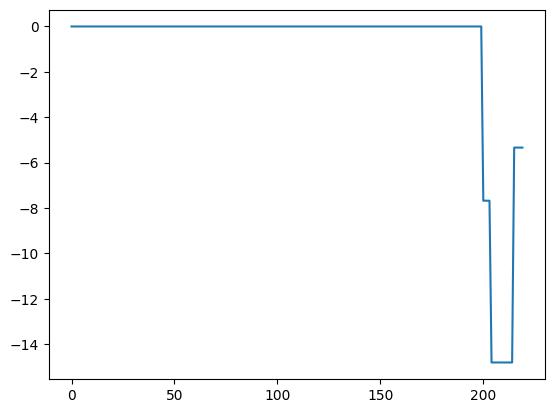

In [1110]:
import matplotlib.pyplot as plt
plt.plot(equity)

In [1111]:
def run_backtest_scale_in(df, tp_mult=1.5, sl_mult=1.0):
    """
    df debe contener:
        - datetime
        - open, high, low, close
        - atr
        - pred_soft_final (0 short, 1 hold, 2 long)
    """

    df = df.sort_values("datetime").reset_index(drop=True)

    open_positions = []   # lista de dicts con posiciones abiertas
    closed_trades = []    # lista de dicts con trades cerrados
    equity_curve = []
    equity = 0.0

    for i, row in df.iterrows():

        # ============================================================
        # 1. Actualizar TODAS las posiciones abiertas (scale-in)
        # ============================================================
        still_open = []

        for pos in open_positions:

            if pos["type"] == "long":

                # SL-first
                if row["low"] <= pos["sl"]:
                    pnl = pos["sl"] - pos["entry"]
                    closed_trades.append({
                        "type": "long",
                        "entry": pos["entry"],
                        "exit": pos["sl"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # TP-second
                elif row["high"] >= pos["tp"]:
                    pnl = pos["tp"] - pos["entry"]
                    closed_trades.append({
                        "type": "long",
                        "entry": pos["entry"],
                        "exit": pos["tp"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # Si no se ha cerrado, sigue abierta
                still_open.append(pos)

            elif pos["type"] == "short":

                # SL-first
                if row["high"] >= pos["sl"]:
                    pnl = pos["entry"] - pos["sl"]
                    closed_trades.append({
                        "type": "short",
                        "entry": pos["entry"],
                        "exit": pos["sl"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                # TP-second
                elif row["low"] <= pos["tp"]:
                    pnl = pos["entry"] - pos["tp"]
                    closed_trades.append({
                        "type": "short",
                        "entry": pos["entry"],
                        "exit": pos["tp"],
                        "pnl": pnl,
                        "datetime_exit": row["datetime"]
                    })
                    equity += pnl
                    continue

                still_open.append(pos)

        open_positions = still_open

        # ============================================================
        # 2. Abrir NUEVAS posiciones (scale-in)
        # ============================================================
        signal = row["pred_soft_final"]

        if signal == 2:  # LONG
            entry = row["open"]
            sl = entry - sl_mult * row["atr"]
            tp = entry + tp_mult * row["atr"]

            open_positions.append({
                "type": "long",
                "entry": entry,
                "sl": sl,
                "tp": tp,
                "datetime_entry": row["datetime"]
            })

        elif signal == 0:  # SHORT
            entry = row["open"]
            sl = entry + sl_mult * row["atr"]
            tp = entry - tp_mult * row["atr"]

            open_positions.append({
                "type": "short",
                "entry": entry,
                "sl": sl,
                "tp": tp,
                "datetime_entry": row["datetime"]
            })

        # ============================================================
        # 3. Guardar equity
        # ============================================================
        equity_curve.append(equity)

    return closed_trades, equity_curve


In [1112]:
trades_s, equity_s = run_backtest_scale_in(df_for_bt)

In [1113]:
trades_s

[{'type': 'long',
  'entry': 1194.5,
  'exit': 1186.8191352229487,
  'pnl': -7.6808647770512835,
  'datetime_exit': Timestamp('2026-05-26 04:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1198.0,
  'exit': 1190.976583859889,
  'pnl': -7.023416140111067,
  'datetime_exit': Timestamp('2026-05-26 04:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1199.0,
  'exit': 1192.1797060119038,
  'pnl': -6.820293988096182,
  'datetime_exit': Timestamp('2026-05-26 04:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1196.25,
  'exit': 1189.9057452103166,
  'pnl': -6.3442547896834185,
  'datetime_exit': Timestamp('2026-05-26 04:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1192.0,
  'exit': 1184.8683125156076,
  'pnl': -7.131687484392387,
  'datetime_exit': Timestamp('2026-05-26 20:00:00+0000', tz='UTC')},
 {'type': 'long',
  'entry': 1188.75,
  'exit': 1182.0025375135267,
  'pnl': -6.747462486473296,
  'datetime_exit': Timestamp('2026-05-27 16:00:00+0000', tz='UTC')},
 {'type

In [1114]:
equity_s

[0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0,
 0.0

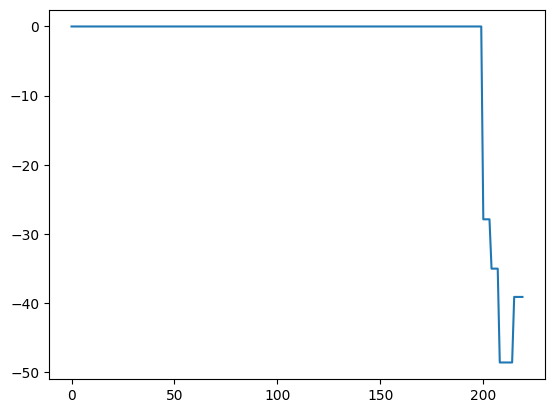

In [1115]:
plt.plot(equity_s)